# 5.2 Анализ поведения адаптивной модели

В этом разделе анализируется как именно ведёт себя адаптивная модель:
- какие решения принимает модель;
- реагирует ли она на ухудшение или улучшение состояния игрока;
- как меняются темп и персональные смещения сложности;
- типичные траектории адаптации внутри сессии.

In [1]:
from importlib import reload
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import notebook_utils as nu

nu = reload(nu)

In [2]:
PREPARED_DIR = Path("data")

task_df = pd.read_csv(PREPARED_DIR / "task_table.csv")
adaptation_df = pd.read_csv(PREPARED_DIR / "adaptation_table.csv")
session_df = pd.read_csv(PREPARED_DIR / "session_table.csv")

## 1. Есть ли шаги адаптации и в каких режимах

In [3]:
adaptation_df["mode"].value_counts(dropna=False)

mode
baseline    1258
ppo          500
Name: count, dtype: int64

## 2. Какие действия модель принимает чаще всего

In [4]:
adaptation_df["delta_tempo"].value_counts(dropna=False).sort_index()

delta_tempo
-1     177
 0    1509
 1      72
Name: count, dtype: int64

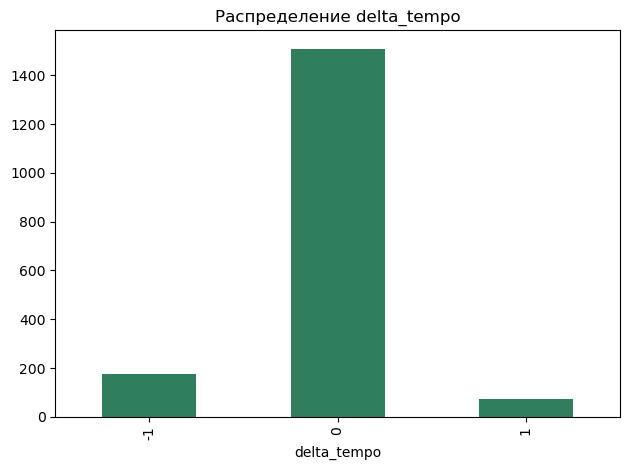

In [5]:
adaptation_df["delta_tempo"].value_counts(dropna=False).sort_index().plot(kind="bar", color="#2f7f5f")
plt.title("Распределение delta_tempo")
plt.xlabel("delta_tempo")
plt.tight_layout()

## 3. Как меняются сложности по отдельным мини-играм

In [6]:
offset_cols = [
    "task_offset_compare_codes",
    "task_offset_sequence_memory",
    "task_offset_rule_switch",
    "task_offset_parity_check",
    "task_offset_radar_scan",
]

adaptation_df[offset_cols].describe()

,task_offset_compare_codes,task_offset_sequence_memory,task_offset_rule_switch,task_offset_parity_check,task_offset_radar_scan
count,1696.000000,1696.000000,1696.000000,1696.000000,1696.000000
mean,-0.149175,-0.149175,-0.149175,-0.150943,-0.149175
std,0.370966,0.370966,0.370966,0.372632,0.370966
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


## 4. Реагирует ли модель на состояние игрока

In [7]:
adaptation_df.groupby("delta_tempo")[["state_accuracy", "state_mean_rt", "state_error_streak", "state_fatigue_trend"]].mean()

,state_accuracy,state_mean_rt,state_error_streak,state_fatigue_trend
delta_tempo,,,,
-1,0.807203,2140.410311,0.361582,8.809457
0,0.890159,2708.068009,0.133863,110.059839
1,0.826389,2636.472222,0.333333,-124.466931


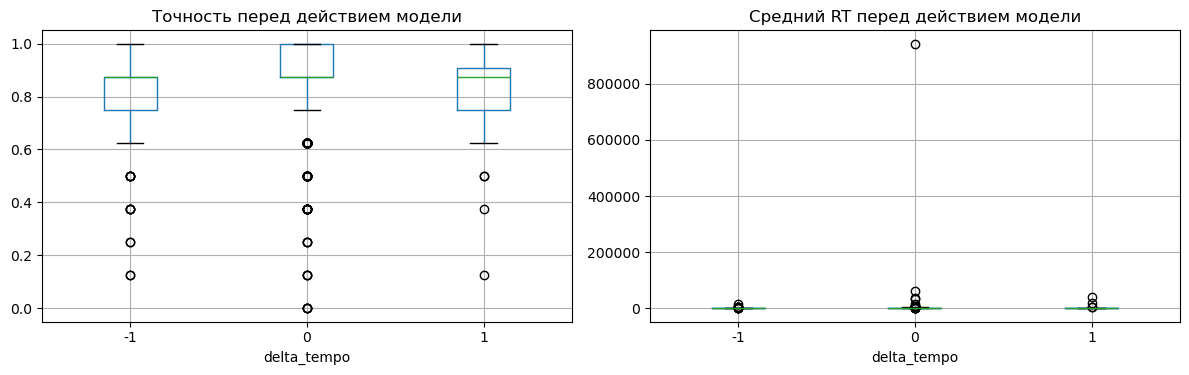

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
adaptation_df.boxplot(column="state_accuracy", by="delta_tempo", ax=axes[0])
adaptation_df.boxplot(column="state_mean_rt", by="delta_tempo", ax=axes[1])
axes[0].set_title("Точность перед действием модели")
axes[1].set_title("Средний RT перед действием модели")
plt.suptitle("")
plt.tight_layout()

## 5. Что происходит после разных действий модели

In [9]:
next_state_view = adaptation_df[["session_id", "step", "delta_tempo", "reward", "state_accuracy", "state_mean_rt"]].copy()
next_state_view["next_accuracy"] = next_state_view.groupby("session_id")["state_accuracy"].shift(-1)
next_state_view["next_mean_rt"] = next_state_view.groupby("session_id")["state_mean_rt"].shift(-1)
next_state_view.groupby("delta_tempo")[["reward", "next_accuracy", "next_mean_rt"]].mean()

,reward,next_accuracy,next_mean_rt
delta_tempo,,,
-1,-0.351019,0.889394,1731.124242
0,-0.494465,0.885956,2755.017340
1,-0.528200,0.753788,2209.253788


## 6. Поведение модели по ходу сессии

In [10]:
adaptation_df["step_bucket"] = pd.cut(
    adaptation_df["step"],
    bins=[-1, 2, 5, 1000],
    labels=["start", "middle", "late"],
)

adaptation_df.groupby(["step_bucket", "delta_tempo"]).size().unstack(fill_value=0)

/var/folders/2z/_grmn59568vdk2lt6w8h6p180000gn/T/ipykernel_39043/2653660688.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adaptation_df.groupby(["step_bucket", "delta_tempo"]).size().unstack(fill_value=0)


delta_tempo,-1,0,1
step_bucket,,,
start,16,197,9
middle,21,158,6
late,140,1154,57


## 7. Типичные траектории внутри отдельных сессий

In [11]:
candidate_sessions = adaptation_df["session_id"].dropna().unique().tolist()[:3]
candidate_sessions

['s1771434254_lera', 's1771434598_lera', 's1772362458_lera']

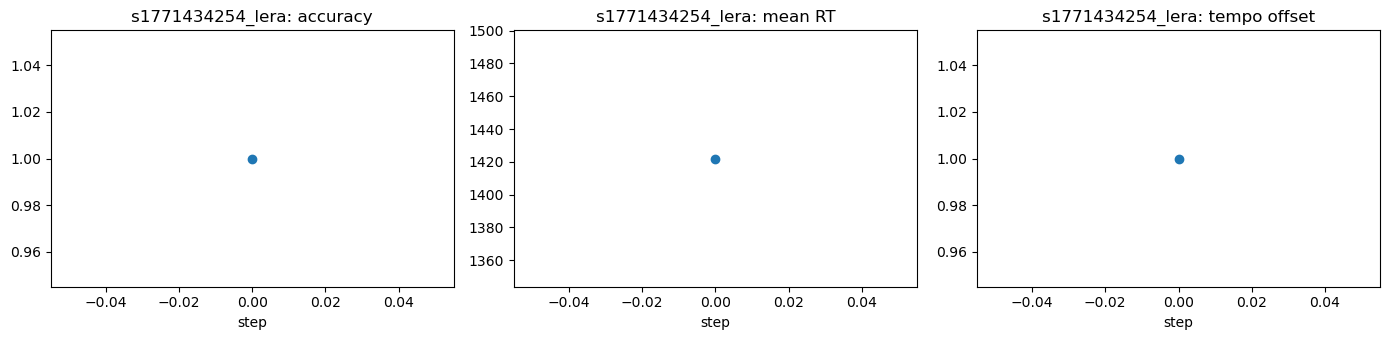

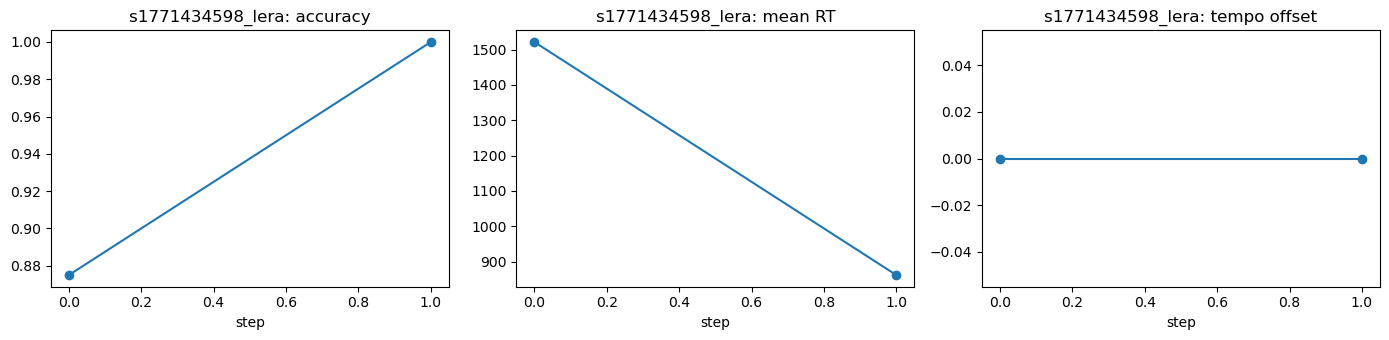

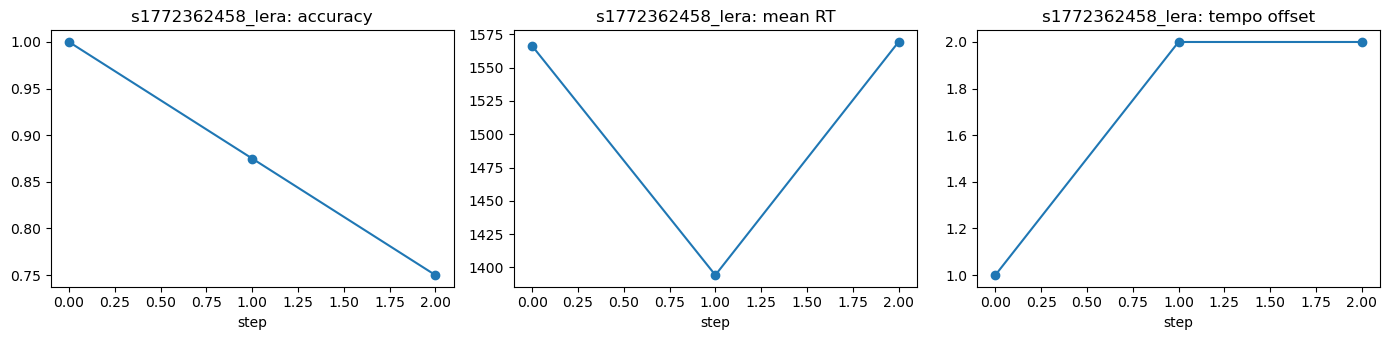

In [12]:
for session_id in candidate_sessions:
    one = adaptation_df[adaptation_df["session_id"] == session_id].sort_values("step")
    if one.empty:
        continue
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
    axes[0].plot(one["step"], one["state_accuracy"], marker="o")
    axes[0].set_title(f"{session_id}: accuracy")
    axes[1].plot(one["step"], one["state_mean_rt"], marker="o")
    axes[1].set_title(f"{session_id}: mean RT")
    axes[2].plot(one["step"], one["tempo_offset"], marker="o")
    axes[2].set_title(f"{session_id}: tempo offset")
    for ax in axes:
        ax.set_xlabel("step")
    plt.tight_layout()
    plt.show()

## 8. Анализ поведения модели по возрасту и гендеру

In [13]:
adaptation_df.groupby(["age_group", "delta_tempo"]).size().unstack(fill_value=0)

delta_tempo,-1,0,1
age_group,,,
0-17,2,15,5
18-20,1,97,1
21-24,30,268,11
25-28,70,484,40
29-34,69,581,14
35-39,5,64,1


In [14]:
adaptation_df.groupby(["gender", "delta_tempo"]).size().unstack(fill_value=0)

delta_tempo,-1,0,1
gender,,,
female,61,415,36
male,116,1094,36
